In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot as plt
import pandas as pd
import pmdarima.arima

In [2]:
df = pd.read_csv('Impute_misvalues_hungyen1.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Impute_misvalues_hungyen1.csv'

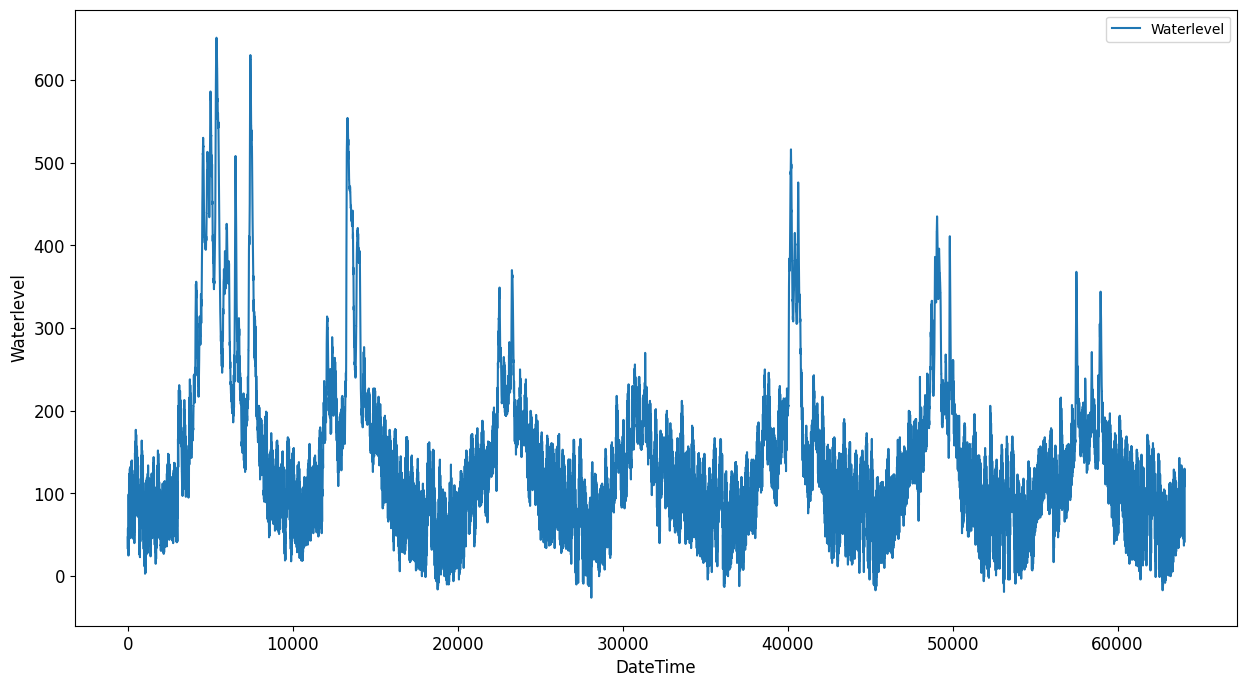

In [ ]:
df.plot(y='Waterlevel', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)
plt.show()

In [ ]:
train_size = int(len(df) * 0.9)
train, test = df[:train_size].iloc[:, [-1]], df[train_size:].iloc[:, [-1]]

train, test

(       Waterlevel
 0            47.0
 1            43.0
 2            40.0
 3            37.0
 4            34.0
 ...           ...
 57649       214.0
 57650       213.0
 57651       212.0
 57652       210.0
 57653       209.0
 
 [57654 rows x 1 columns],
        Waterlevel
 57654       207.0
 57655       205.0
 57656       204.0
 57657       201.0
 57658       198.0
 ...           ...
 64056       127.0
 64057       124.0
 64058       120.0
 64059       115.0
 64060       109.0
 
 [6407 rows x 1 columns])

In [ ]:
train_data = train.values
test_data = test.values

In [ ]:
timesteps=5

In [ ]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] for i in range(0,len(train_data)-timesteps+1)])[:,:,0]
train_data_timesteps.shape

In [ ]:
test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] for i in range(0,len(test_data)-timesteps+1)])[:,:,0]
test_data_timesteps.shape

In [ ]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    for key, value in result[4].items():
        print('Critial Values:')
        print(f'   {key}, {value}')

In [ ]:
check_stationarity(df['Waterlevel'])

ADF Statistic: -7.251277920680257
p-value: 1.7774156060489135e-10
Critial Values:
   1%, -3.4304521822576093
Critial Values:
   5%, -2.8615851626770272
Critial Values:
   10%, -2.566794038561404


In [ ]:
auto_model = pmdarima.arima.auto_arima(train, seasonal=False, error_action='ignore', trace=True,
                                              suppress_warnings=True, maxiter=20, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=259962.391, Time=22.79 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=374517.930, Time=0.79 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=280220.616, Time=1.89 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=321281.216, Time=5.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=374515.941, Time=0.37 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=267993.345, Time=7.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=261235.850, Time=20.66 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=261309.472, Time=22.42 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=259530.307, Time=25.86 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=267187.894, Time=11.29 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=259459.481, Time=28.12 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=259223.686, Time=32.40 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=29.48 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=259322.910, Time=37.00 sec
 AR

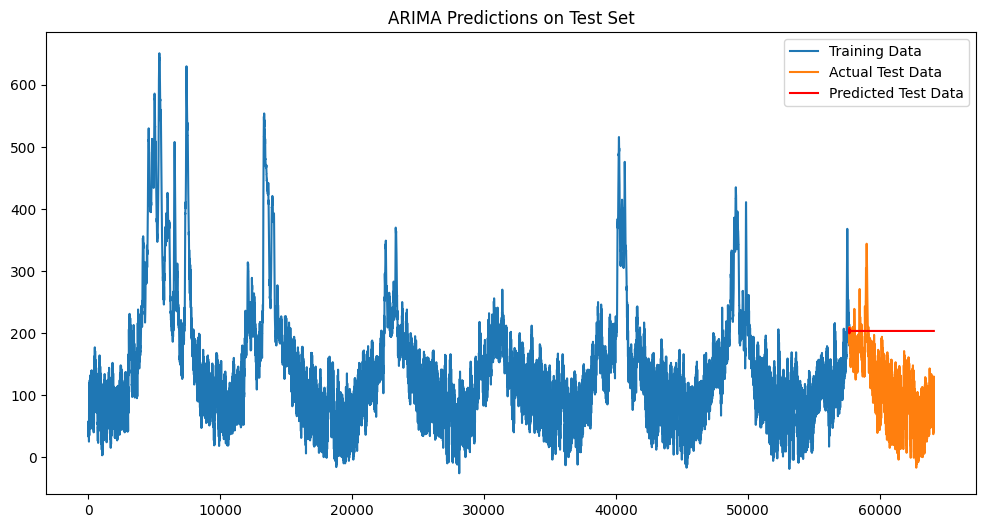

In [ ]:
prediction_results = auto_model.predict(n_periods=len(test))
test['Predictions'] = prediction_results

# comparison = pd.DataFrame({'Actual': test, 'Predicted': prediction_results})

# comparison


# Plot actual vs predicted values

plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test.iloc[:, 0], label='Actual Test Data')
plt.plot(test.index, prediction_results, label='Predicted Test Data', color='r')
plt.title('ARIMA Predictions on Test Set')
plt.legend()
plt.show()